sankey chart / Alluvial Diagram 

In [1]:
# imports
import pandas as pd
import matplotlib as plt
import math

In [2]:
# set display options for pandas
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.float_format", "{:.2f}".format)

In [3]:
# constants
years = [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
normalizedColumns = ["fund_type", "fund_description", "department_description", "appropriation_authority_description",  "appropriation_account_description"]

In [4]:
# helper functions
def getRowAmount(row):
    if not pd.isna(row["_ordinance_amount_"]):
        return row["_ordinance_amount_"]
    elif not pd.isna(row["appropriation_ordinance"]):
        return row["appropriation_ordinance"]
    else:
        return row["amount"]

def fmtCode(code, length):
    return "0" * (length - len(str(code))) + str(code) # if isinstance(code, float) and not math.isnan(code) else code

def getAnnualBudget(df, year):
    return df[df["year"] == year]["amount"].sum()

def getAnnualFundType(df, year, fundType):
    return df[(df["year"] == year) & (df["fund_type"] == fundType)]["amount"].sum()

def getAnnualGrantFunds(df, year):
    return getAnnualFundType(df, year, "GRANTS") + getAnnualFundType(df, year, "CDBG")

def getAnnualLocalFunds(df, year):
    return getAnnualFundType(df, year, "LOCAL")

def getBreakdown(df, indexCol, nameCol):
    valueCounts = df[[indexCol, nameCol]].value_counts().to_frame().reset_index()
    nameCounts = valueCounts[indexCol].value_counts().to_frame().reset_index()

    mult = nameCounts.drop("count", axis=1)
    mult["count"] = mult.apply(lambda row: valueCounts[valueCounts[indexCol] == row[indexCol]]["count"].sum(), axis=1)
    mult["names"] = mult.apply(lambda row: valueCounts[valueCounts[indexCol] == row[indexCol]][nameCol].to_list(), axis=1)
    return mult.sort_values(by=indexCol).set_index(indexCol)

In [5]:
# import all ordinance files and combine into table
df = pd.DataFrame()
for year in years:
    dfYear = pd.read_csv(f"data/{year}-ordinance.csv")
    dfYear["year"] = year
    df = pd.concat([df, dfYear], ignore_index=True)


# clean rows and columns
df["amount"] = df.apply(getRowAmount, axis=1)
df["fund_code"] = df.apply(lambda row: fmtCode(row["fund_code"], 4), axis=1)
df["department_number"] = df.apply(lambda row: fmtCode(row["department_number"], 2), axis=1)
df["appropriation_account"] = df.apply(lambda row: fmtCode(row["appropriation_account"], 4), axis=1)
df["appropriation_authority"] = df["appropriation_authority"].apply(lambda x: str(int(x)) if isinstance(x, float) and not math.isnan(x) else x)
df["appropriation_authority"] = df.apply(lambda row: fmtCode(row["appropriation_authority"], 4), axis=1)
df = df.drop(columns=["department", "_ordinance_amount_", "appropriation_ordinance"])

for colName in normalizedColumns:
    df[colName] = df[colName].str.upper()

df.head()

,fund_type,fund_code,fund_description,department_number,department_description,appropriation_authority,appropriation_authority_description,appropriation_account,appropriation_account_description,amount,year
0,LOCAL,0100,CORPORATE FUND,55,POLICE BOARD,2005,2005 - POLICE BOARD,0050,STIPENDS,145000.00,2011
1,LOCAL,0100,CORPORATE FUND,55,POLICE BOARD,2005,2005 - POLICE BOARD,0130,POSTAGE,300.00,2011
2,LOCAL,0100,CORPORATE FUND,39,BOARD OF ELECTION COMMISSIONER,2005,2005 - ELECTION AND ADMIN DIVISION,0005,SALARIES AND WAGES - ON PAYROLL,6831849.00,2011
3,LOCAL,0100,CORPORATE FUND,39,BOARD OF ELECTION COMMISSIONER,2005,2005 - ELECTION AND ADMIN DIVISION,0015,SCHEDULE SALARY ADJ,27342.00,2011
4,LOCAL,0100,CORPORATE FUND,39,BOARD OF ELECTION COMMISSIONER,2005,2005 - ELECTION AND ADMIN DIVISION,0030,LESS SALARY SAVINGS FROM UNPAID TIME OFF,-607288.00,2011


In [6]:
# More Info from 2026 Budget Breakdown: https://public.tableau.com/app/profile/obm.data.analytics/viz/CityofChicago-BudgetataGlance/ChicagoBudgetataGlance?publish=yes
# Proceeds of debt issuances transferred between funds and reimbursements or internal transfers between funds need to be deducted to more accurately reflect the City appropriation.
# Total resources include revenues generated during the year.
budgets = pd.DataFrame(
    {
        "year": years,
        "total": list(map(lambda x: int(getAnnualBudget(df, x)), years)),
        "local": list(map(lambda x: int(getAnnualLocalFunds(df, x)), years)),
        "grants": list(map(lambda x: int(getAnnualGrantFunds(df, x)), years)),
    }
)
budgets = budgets.set_index("year")
budgets

,total,local,grants
year,,,
2011,8700334637,6567524000,2132810637
2012,8614865000,6693285000,1921580000
2013,8745336000,6938504000,1806832000
2014,9114711000,7402555000,1712156000
2015,9555106000,7987039000,1568067000
2016,10056354000,8554560000,1501794000
2017,10677480000,9048324000,1629156000
2018,10752004000,9310802000,1441202000
2019,11400085000,9589147000,1810938000


<Axes: xlabel='year'>

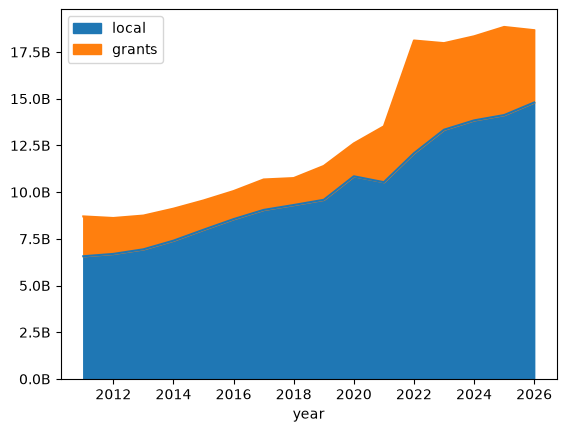

In [7]:
def billions_formatter(x, pos):
    return f"{x * 1e-9:,.1f}B"

ax = budgets.drop(["total"], axis=1).plot.area()
ax.yaxis.set_major_formatter(plt.ticker.FuncFormatter(billions_formatter))
ax

In [8]:
# More Info from Office of Inspector General: https://igchicago.org/information-portal/data-dashboards/city-budget-by-departments/
# Local funds are used by the City for non-capital operations with sources other than grant funds. These include the Corporate Fund, O’Hare Revenue Fund, Water Fund, and other similar funds.
# Grants are financial awards given by the federal, state, or local government authority restricted for a specific project or service.
# Community Development Block Grant (CDBG) funds are provided by federal and state governments to communities and people to be used in a variety of ways including housing, community development programs, healthy food initiatives, and sustainability services.
funds = getBreakdown(df, "fund_code", "fund_description")
funds["fund_type"] = funds.index.map(lambda i: df[df["fund_code"] == i].iloc[0]["fund_type"])
funds = funds[["fund_type", "count", "names"]]
funds.head(10)

,fund_type,count,names
fund_code,,,
0006,GRANTS,1,[FTA]
0011,GRANTS,5,"[GREENSTREETS, GREEN STREETS]"
0017,GRANTS,13,[FEDERAL HIGHWAY BRIDGE]
001C,GRANTS,1,[FAMILES FIRST COVID RESPONSE ACT TITLE I]
0020,GRANTS,43,[SR CITIZEN NUTRITION/SOC SERV]
0023,GRANTS,9,[UNDERGROUND STORAGE TANK]
0027,GRANTS,2,"[GROUP ""A"" PRELIMINARY ENGINEER]"
002C,GRANTS,2,[HOUSING OPPORTUNITIES FOR PEOPLE WITH AI]
003C,GRANTS,1,[CORONAVIRUS RELIEF]


In [9]:
valueCounts = getBreakdown(df, "department_number", "department_description")
valueCounts.head(10)

,count,names
department_number,,
01,480,"[OFFICE OF THE MAYOR, MAYOR, MO]"
03,1518,"[OIG, OFFICE OF INSPECTOR GENERAL, IG, INSPECTOR GENERAL]"
05,718,"[OBM, OFFICE OF BUDGET & MANAGEMENT, OFFICE OF BUDGET AND MANAGEMENT]"
06,563,"[DOIT, DEPARTMENT OF TECHNOLOGY AND INNOVATION, DEPARTMENT OF INNOVATION AND TECHNOLOGY]"
15,1559,"[CITY COUNCIL, COUNCIL]"
21,808,"[DEPARTMENT OF HOUSING, DOH, HOUSING]"
23,807,"[DCASE, CULTURAL AFFAIRS SPECIAL EVENT, DEPARTMENT OF CULTURAL AFFAIRS AND SPECIAL EVENTS]"
25,513,"[CITY CLERK, OFFICE OF CITY CLERK, CLERK]"
27,2384,"[FINANCE, DEPARTMENT OF FINANCE, DOF]"


In [10]:
accounts = getBreakdown(df, "appropriation_account", "appropriation_account_description")
accounts.head(10)

,count,names
appropriation_account,,
0000,342,[PERSONNEL SERVICES]
0001,5,[SALARIES AND WAGES]
0003,187,[SCHEDULED WAGE ADJUSTMENTS]
0005,3770,[SALARIES AND WAGES - ON PAYROLL]
0006,566,[SALARY PROVISION]
0008,47,"[PAYMENT RETROACTIVE SALARIES, FOR PAYMENT OF RETROACTIVE SALARIES]"
0010,5,"[SAL AND WAGES-ON VOUCHER, SALARIES AND WAGES - ON VOUCHER]"
0011,453,"[CONTRACT WAGE - SALARY, CONTRACT WAGE-SALARY, CONTRACT WAGE INCREMENT - SALARY]"
0012,663,"[CONTRACT WAGE - PREVAILING RATE, CONTRACT WAGE-PR, CONTRACT WAGE INCREMENT - PREVAILING RATE]"


In [11]:
# authorities = getBreakdown(df, "appropriation_authority", "appropriation_authority_description")
# authorities.head()

In [12]:
trimmedDf = (
    df[["year", "department_number", "appropriation_account", "fund_code", 'amount']]
    .sort_values(["year", "department_number", "appropriation_account", "fund_code", 'amount'])
    .reset_index(drop=True)
)
trimmedDf.head()

,year,department_number,appropriation_account,fund_code,amount
0,2011,01,0005,0100,5892558.00
1,2011,01,0005,0355,384120.00
2,2011,01,0030,0100,-519910.00
3,2011,01,0030,0355,-36432.00
4,2011,01,0126,0100,1310.00


In [14]:
trimmedDf[trimmedDf["year"] == 2026].reset_index(drop=True).head(10)

,year,department_number,appropriation_account,fund_code,amount
0,2026,01,0005,0100,10707977.00
1,2026,01,0005,0355,470873.00
2,2026,01,0005,0B21,124909.00
3,2026,01,0005,0B70,806222.00
4,2026,01,0005,925L,95867.00
5,2026,01,0005,925L,172505.00
6,2026,01,0005,GA00,106529.00
7,2026,01,0006,925L,45827.00
8,2026,01,0006,GA00,1013.00
9,2026,01,0039,0100,57490.00
